## Install Dependencies

In [1]:
!pip install datasets nltk spacy gensim scikit-learn matplotlib seaborn wordcloud --quiet
!python -m spacy download en_core_web_sm --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 36.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 52.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## Import Libraries

In [2]:
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import spacy

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from gensim.models import Word2Vec

from datasets import load_dataset

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)

nlp = spacy.load('en_core_web_sm')

print('All libraries loaded successfully.')

All libraries loaded successfully.


## Load Dataset from HuggingFace

In [3]:
dataset = load_dataset('imdb')

# Use 2000 samples for efficiency in Colab
train_data = dataset['train'].shuffle(seed=42).select(range(2000))

df = pd.DataFrame({
    'text': train_data['text'],
    'label': train_data['label']
})

df['sentiment'] = df['label'].map({0: 'negative', 1: 'positive'})

print(f'Dataset shape: {df.shape}')
print(f'\nSentiment distribution:')
print(df['sentiment'].value_counts())
print(f'\nSample review:')
print(df['text'][0][:300])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Dataset shape: (2000, 3)

Sentiment distribution:
sentiment
positive    1000
negative    1000
Name: count, dtype: int64

Sample review:
There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. Fortier's plot are far more complicated... Fortier looks more like Prime Suspect, if we have to spot 


## Step 1: Text Cleaning

In [4]:
def clean_text(text):
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Convert to lowercase
    text = text.lower()
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned_text'] = df['text'].apply(clean_text)

print('Text cleaning complete.')
print(f'\nOriginal text sample:')
print(df['text'][0][:200])
print(f'\nCleaned text sample:')
print(df['cleaned_text'][0][:200])

# Compare average lengths
print(f'\nAverage original length (chars): {df["text"].str.len().mean():.0f}')
print(f'Average cleaned length (chars): {df["cleaned_text"].str.len().mean():.0f}')

Text cleaning complete.

Original text sample:
There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. F

Cleaned text sample:
there is no relation at all between fortier and profiler but the fact that both are police series about violent crimes profiler looks crispy fortier looks classic profiler plots are quite simple forti

Average original length (chars): 1294
Average cleaned length (chars): 1225


## Step 2: Tokenization

In [5]:
df['tokens'] = df['cleaned_text'].apply(word_tokenize)

print('Tokenization complete.')
print(f'\nSample tokens (first 20):')
print(df['tokens'][0][:20])

print(f'\nAverage number of tokens per review: {df["tokens"].apply(len).mean():.0f}')
print(f'Max tokens in a review: {df["tokens"].apply(len).max()}')
print(f'Min tokens in a review: {df["tokens"].apply(len).min()}')

Tokenization complete.

Sample tokens (first 20):
['there', 'is', 'no', 'relation', 'at', 'all', 'between', 'fortier', 'and', 'profiler', 'but', 'the', 'fact', 'that', 'both', 'are', 'police', 'series', 'about', 'violent']

Average number of tokens per review: 223
Max tokens in a review: 991
Min tokens in a review: 12


## Step 3: Stopword Removal

In [6]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words and len(word) > 1]

df['tokens_no_stopwords'] = df['tokens'].apply(remove_stopwords)

print('Stopword removal complete.')
print(f'\nSample stopwords used: {list(stop_words)[:10]}')
print(f'\nTokens before stopword removal (sample): {df["tokens"][0][:15]}')
print(f'Tokens after stopword removal (sample): {df["tokens_no_stopwords"][0][:15]}')

avg_before = df['tokens'].apply(len).mean()
avg_after = df['tokens_no_stopwords'].apply(len).mean()
print(f'\nAverage tokens before removal: {avg_before:.0f}')
print(f'Average tokens after removal:  {avg_after:.0f}')
print(f'Reduction: {((avg_before - avg_after) / avg_before * 100):.1f}%')

Stopword removal complete.

Sample stopwords used: ['than', 'itself', "won't", 'with', "hasn't", 'mightn', 'further', 'himself', "shouldn't", "i'll"]

Tokens before stopword removal (sample): ['there', 'is', 'no', 'relation', 'at', 'all', 'between', 'fortier', 'and', 'profiler', 'but', 'the', 'fact', 'that', 'both']
Tokens after stopword removal (sample): ['relation', 'fortier', 'profiler', 'fact', 'police', 'series', 'violent', 'crimes', 'profiler', 'looks', 'crispy', 'fortier', 'looks', 'classic', 'profiler']

Average tokens before removal: 223
Average tokens after removal:  117
Reduction: 47.5%


## Step 4: Lemmatization

In [7]:
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df['lemmatized_tokens'] = df['tokens_no_stopwords'].apply(lemmatize_tokens)

# Also create a single string version for vectorizers
df['processed_text'] = df['lemmatized_tokens'].apply(lambda x: ' '.join(x))

print('Lemmatization complete.')
print(f'\nBefore lemmatization: {df["tokens_no_stopwords"][0][:10]}')
print(f'After lemmatization:  {df["lemmatized_tokens"][0][:10]}')

# Show specific lemmatization examples
examples = ['running', 'flies', 'better', 'studies', 'was', 'dogs']
print(f'\nLemmatization examples:')
for word in examples:
    print(f'  {word} -> {lemmatizer.lemmatize(word)}')

Lemmatization complete.

Before lemmatization: ['relation', 'fortier', 'profiler', 'fact', 'police', 'series', 'violent', 'crimes', 'profiler', 'looks']
After lemmatization:  ['relation', 'fortier', 'profiler', 'fact', 'police', 'series', 'violent', 'crime', 'profiler', 'look']

Lemmatization examples:
  running -> running
  flies -> fly
  better -> better
  studies -> study
  was -> wa
  dogs -> dog


## Step 5: Vocabulary Creation

In [8]:
all_tokens = [token for tokens in df['lemmatized_tokens'] for token in tokens]

vocab_counter = Counter(all_tokens)

# Full vocabulary
vocab = sorted(vocab_counter.keys())
word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for word, idx in word2idx.items()}

print(f'Total tokens (with repetition): {len(all_tokens)}')
print(f'Unique vocabulary size: {len(vocab)}')
print(f'\nTop 20 most frequent words:')
for word, count in vocab_counter.most_common(20):
    print(f'  {word}: {count}')

print(f'\nBottom 10 least frequent words:')
for word, count in vocab_counter.most_common()[:-11:-1]:
    print(f'  {word}: {count}')

Total tokens (with repetition): 233909
Unique vocabulary size: 28223

Top 20 most frequent words:
  movie: 4081
  film: 3643
  one: 2137
  like: 1583
  good: 1182
  time: 1176
  character: 1101
  even: 1031
  would: 1017
  make: 985
  get: 960
  story: 946
  see: 916
  really: 914
  scene: 850
  people: 762
  well: 751
  much: 729
  bad: 708
  show: 706

Bottom 10 least frequent words:
  scurry: 1
  roach: 1
  revoked: 1
  musicsure: 1
  pointlessly: 1
  ream: 1
  castro: 1
  avert: 1
  flute: 1
  idiotthe: 1


## Step 6: Bag of Words and TF-IDF Vectors

In [9]:
# Bag of Words
bow_vectorizer = CountVectorizer(max_features=5000, min_df=2, max_df=0.95)
bow_matrix = bow_vectorizer.fit_transform(df['processed_text'])

print('Bag of Words')
print(f'  Matrix shape: {bow_matrix.shape}')
print(f'  Vocabulary size (BoW): {len(bow_vectorizer.vocabulary_)}')
print(f'  Sample features: {bow_vectorizer.get_feature_names_out()[:10].tolist()}')
print(f'  Matrix density: {bow_matrix.nnz / (bow_matrix.shape[0] * bow_matrix.shape[1]):.4f}')

print()

# TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.95)
tfidf_matrix = tfidf_vectorizer.fit_transform(df['processed_text'])

print('TF-IDF')
print(f'  Matrix shape: {tfidf_matrix.shape}')
print(f'  Vocabulary size (TF-IDF): {len(tfidf_vectorizer.vocabulary_)}')

# Top TF-IDF terms for a sample document
sample_idx = 0
feature_names = tfidf_vectorizer.get_feature_names_out()
sample_vector = tfidf_matrix[sample_idx].toarray().flatten()
top_indices = sample_vector.argsort()[-10:][::-1]
print(f'\nTop 10 TF-IDF terms for review[0]:')
for idx in top_indices:
    print(f'  {feature_names[idx]}: {sample_vector[idx]:.4f}')

Bag of Words
  Matrix shape: (2000, 5000)
  Vocabulary size (BoW): 5000
  Sample features: ['abandon', 'abandoned', 'ability', 'able', 'absence', 'absent', 'absolute', 'absolutely', 'absorbing', 'absurd']
  Matrix density: 0.0155

TF-IDF
  Matrix shape: (2000, 5000)
  Vocabulary size (TF-IDF): 5000

Top 10 TF-IDF terms for review[0]:
  series: 0.3120
  look: 0.3101
  american: 0.3096
  evaluate: 0.1902
  weirdo: 0.1864
  similarity: 0.1800
  funny: 0.1779
  superficial: 0.1773
  relation: 0.1748
  prefer: 0.1748


## Step 7: Word Embeddings (Word2Vec)

In [10]:
sentences = df['lemmatized_tokens'].tolist()

# Train Word2Vec model
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=10,
    sg=1  # Skip-gram
)

print('Word2Vec model trained.')
print(f'Vocabulary size in Word2Vec: {len(w2v_model.wv)}')
print(f'Vector dimension: {w2v_model.vector_size}')

# Similar words
test_words = ['film', 'story', 'bad', 'good']
for word in test_words:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=5)
        print(f'\nWords similar to "{word}":')
        for sim_word, score in similar:
            print(f'  {sim_word}: {score:.4f}')

Word2Vec model trained.
Vocabulary size in Word2Vec: 12586
Vector dimension: 100

Words similar to "film":
  awe: 0.7393
  moviei: 0.7252
  movie: 0.7183
  anime: 0.7180
  riveting: 0.7136

Words similar to "story":
  tale: 0.6733
  plot: 0.6446
  idea: 0.6427
  difference: 0.6241
  clichs: 0.6237

Words similar to "bad":
  terrible: 0.7114
  awful: 0.6937
  crappy: 0.6934
  laughably: 0.6934
  horrible: 0.6912

Words similar to "good":
  shoddy: 0.7049
  improved: 0.6959
  sarah: 0.6920
  decent: 0.6896
  improvement: 0.6881


## Step 8: Sentence Embeddings

In [11]:
def get_sentence_embedding(tokens, model):
    vectors = []
    for token in tokens:
        if token in model.wv:
            vectors.append(model.wv[token])
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size)

df['sentence_embedding'] = df['lemmatized_tokens'].apply(
    lambda tokens: get_sentence_embedding(tokens, w2v_model)
)

# Build embedding matrix
embedding_matrix = np.vstack(df['sentence_embedding'].values)

print('Sentence embeddings created.')
print(f'Embedding matrix shape: {embedding_matrix.shape}')
print(f'Sample embedding (first 10 dims of review 0):')
print(np.round(embedding_matrix[0][:10], 4))

# Verify embeddings are non-zero
non_zero = np.sum(np.any(embedding_matrix != 0, axis=1))
print(f'\nReviews with valid embeddings: {non_zero}/{len(df)}')

Sentence embeddings created.
Embedding matrix shape: (2000, 100)
Sample embedding (first 10 dims of review 0):
[-0.1132  0.1642 -0.1483  0.2222 -0.0108 -0.2295  0.0844  0.4657 -0.1141
 -0.2323]

Reviews with valid embeddings: 2000/2000


## Step 9: Similarity Search

In [12]:
def find_similar_reviews(query_idx, embedding_matrix, df, top_n=5):
    query_vec = embedding_matrix[query_idx].reshape(1, -1)
    similarities = cosine_similarity(query_vec, embedding_matrix).flatten()
    similarities[query_idx] = -1  # exclude self
    top_indices = similarities.argsort()[-top_n:][::-1]
    return top_indices, similarities[top_indices]

# Run similarity search for query review index 0
query_idx = 0
top_indices, scores = find_similar_reviews(query_idx, embedding_matrix, df, top_n=5)

print(f'Query Review ({df["sentiment"][query_idx]}):')
print(df['text'][query_idx][:200])
print()

print('Top 5 similar reviews:')
print('-' * 60)
for rank, (idx, score) in enumerate(zip(top_indices, scores), 1):
    print(f'\nRank {rank} | Index: {idx} | Sentiment: {df["sentiment"][idx]} | Similarity: {score:.4f}')
    print(df['text'][idx][:150])

# TF-IDF based similarity search for comparison
print('\n' + '=' * 60)
print('TF-IDF Similarity Search (same query):')
print('=' * 60)
tfidf_query = tfidf_matrix[query_idx]
tfidf_sims = cosine_similarity(tfidf_query, tfidf_matrix).flatten()
tfidf_sims[query_idx] = -1
tfidf_top = tfidf_sims.argsort()[-5:][::-1]
for rank, idx in enumerate(tfidf_top, 1):
    print(f'\nRank {rank} | Index: {idx} | Sentiment: {df["sentiment"][idx]} | Similarity: {tfidf_sims[idx]:.4f}')
    print(df['text'][idx][:150])

Query Review (positive):
There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. F

Top 5 similar reviews:
------------------------------------------------------------

Rank 1 | Index: 82 | Sentiment: negative | Similarity: 0.9718
Man, I really find it hard to believe that the wonderful Alan Ball had anything to do with this mess. Having seen the first two episodes thus far, I t

Rank 2 | Index: 1334 | Sentiment: negative | Similarity: 0.9699
This movie is written by Charlie Higson, who has before this done the "legendary" Fast Show and his own show based on one of Fast Show's characters (T

Rank 3 | Index: 866 | Sentiment: positive | Similarity: 0.9694
I actually really like what I've seen of this cartoon so far. Sure, the animation isn't the best, but frankly, I'd rather see this type of more cartoo

Rank 4 | Index: 470 | Sentiment: negative |

## Step 10: Insights and Visualization

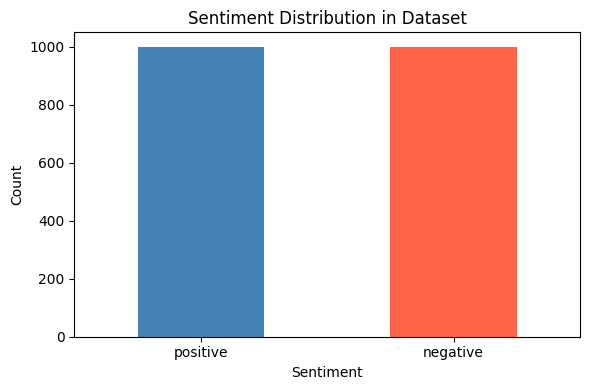

In [13]:
# Plot 1: Sentiment Distribution
plt.figure(figsize=(6, 4))
df['sentiment'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Sentiment Distribution in Dataset')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

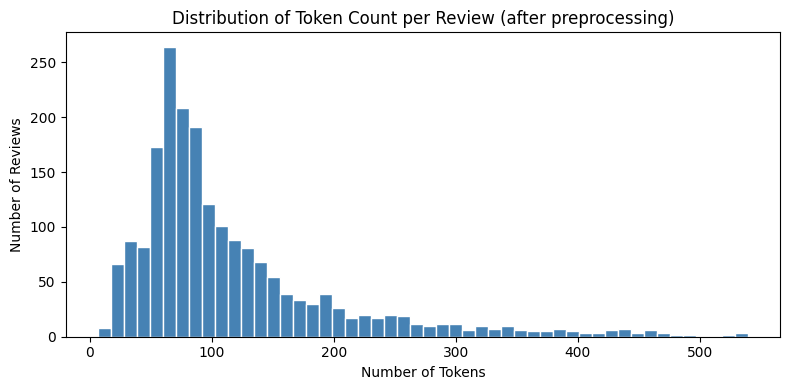

Mean tokens per review: 117.0
Median tokens per review: 88.0


In [14]:
# Plot 2: Token count distribution
plt.figure(figsize=(8, 4))
df['token_count'] = df['lemmatized_tokens'].apply(len)
plt.hist(df['token_count'], bins=50, color='steelblue', edgecolor='white')
plt.title('Distribution of Token Count per Review (after preprocessing)')
plt.xlabel('Number of Tokens')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

print(f'Mean tokens per review: {df["token_count"].mean():.1f}')
print(f'Median tokens per review: {df["token_count"].median():.1f}')

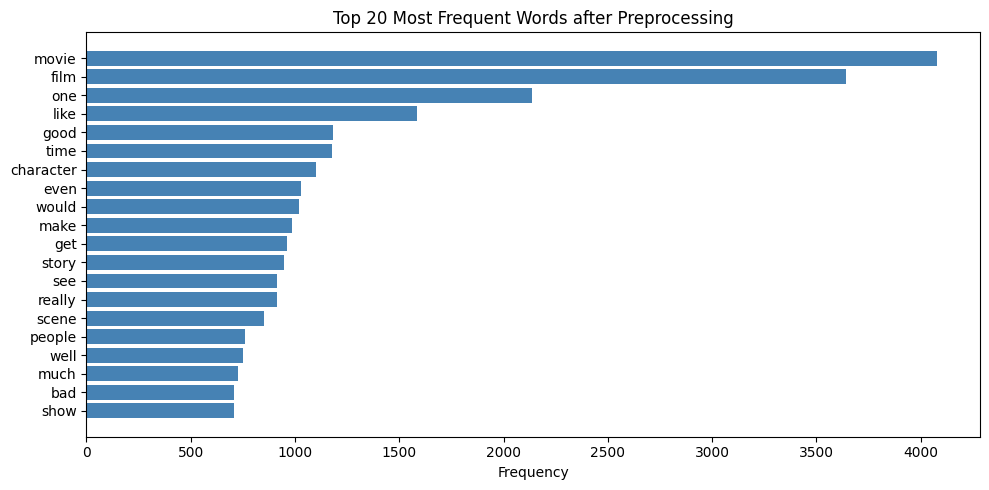

In [15]:
# Plot 3: Top 20 Most Frequent Words
top_words = vocab_counter.most_common(20)
words, counts = zip(*top_words)

plt.figure(figsize=(10, 5))
plt.barh(words[::-1], counts[::-1], color='steelblue')
plt.title('Top 20 Most Frequent Words after Preprocessing')
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()

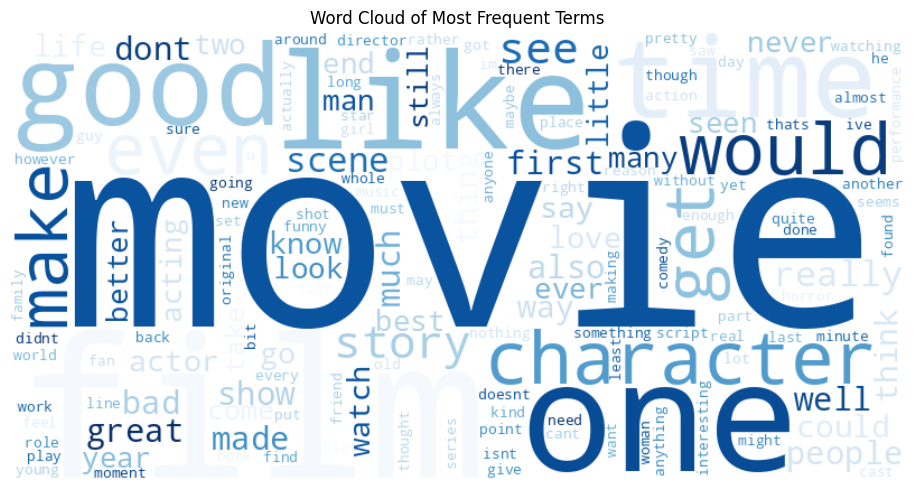

In [16]:
# Plot 4: Word Cloud
word_freq_dict = dict(vocab_counter.most_common(200))

wc = WordCloud(width=800, height=400, background_color='white',
               colormap='Blues', max_words=150)
wc.generate_from_frequencies(word_freq_dict)

plt.figure(figsize=(12, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Most Frequent Terms')
plt.tight_layout()
plt.show()

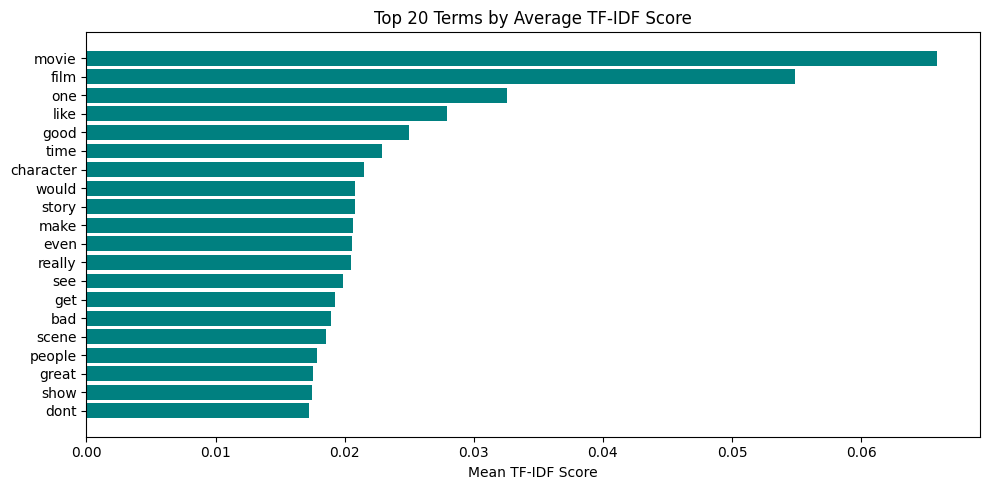

In [17]:
# Plot 5: TF-IDF Score Distribution for Top Terms
tfidf_scores = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
feature_names = tfidf_vectorizer.get_feature_names_out()
top20_tfidf_idx = tfidf_scores.argsort()[-20:][::-1]

plt.figure(figsize=(10, 5))
plt.barh(
    [feature_names[i] for i in top20_tfidf_idx][::-1],
    tfidf_scores[top20_tfidf_idx][::-1],
    color='teal'
)
plt.title('Top 20 Terms by Average TF-IDF Score')
plt.xlabel('Mean TF-IDF Score')
plt.tight_layout()
plt.show()

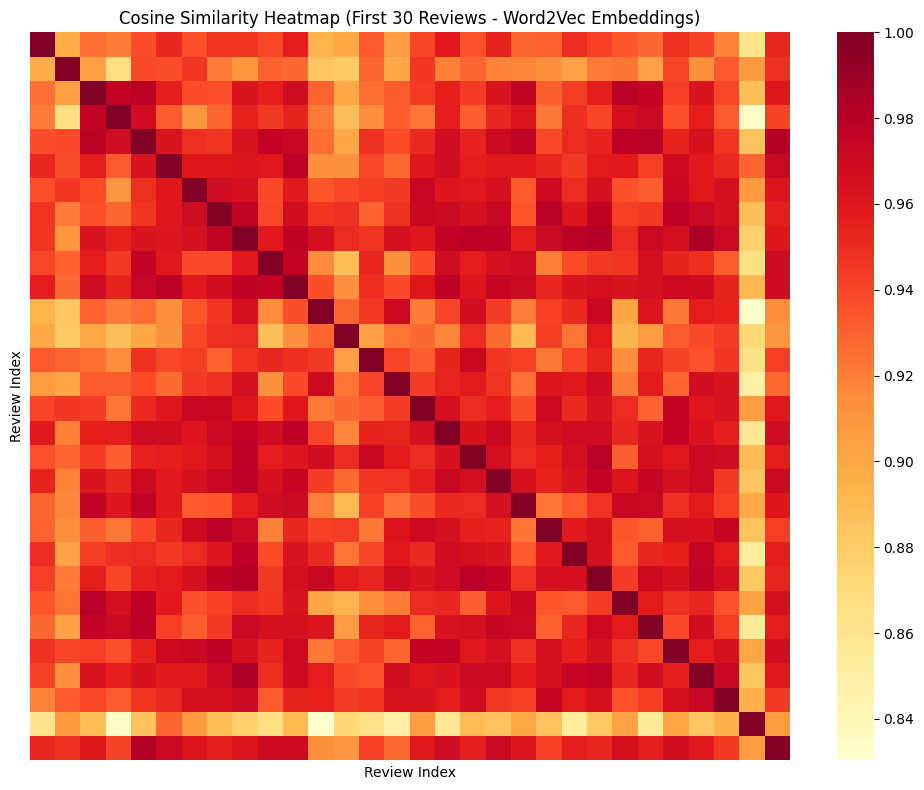

In [18]:
# Plot 6: Similarity Heatmap (subset of reviews)
subset = 30
sim_subset = cosine_similarity(embedding_matrix[:subset])

plt.figure(figsize=(10, 8))
sns.heatmap(sim_subset, cmap='YlOrRd', xticklabels=False, yticklabels=False)
plt.title(f'Cosine Similarity Heatmap (First {subset} Reviews - Word2Vec Embeddings)')
plt.xlabel('Review Index')
plt.ylabel('Review Index')
plt.tight_layout()
plt.show()

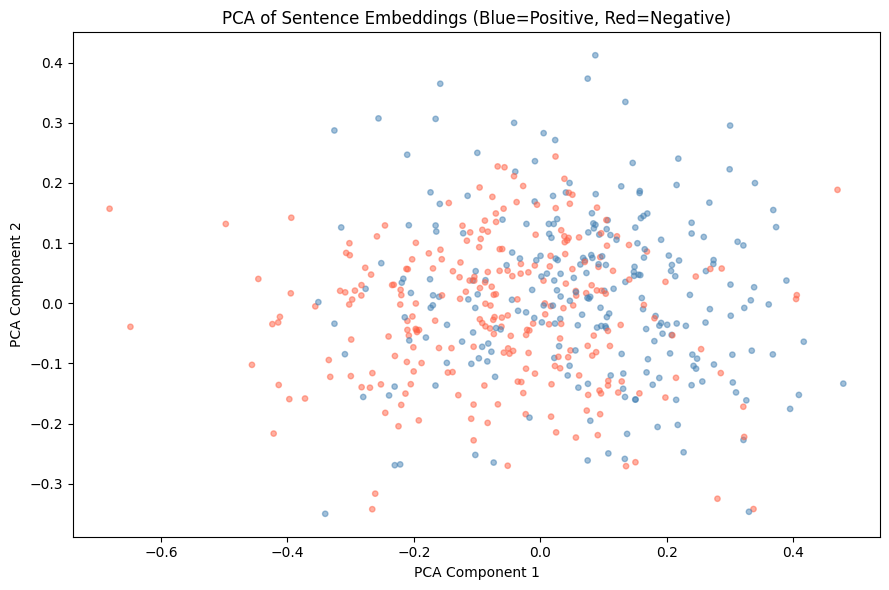

In [19]:
# Plot 7: PCA visualization of sentence embeddings
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
reduced = pca.fit_transform(embedding_matrix[:500])

colors = ['steelblue' if s == 'positive' else 'tomato' for s in df['sentiment'][:500]]

plt.figure(figsize=(9, 6))
plt.scatter(reduced[:, 0], reduced[:, 1], c=colors, alpha=0.5, s=15)
plt.title('PCA of Sentence Embeddings (Blue=Positive, Red=Negative)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.tight_layout()
plt.show()

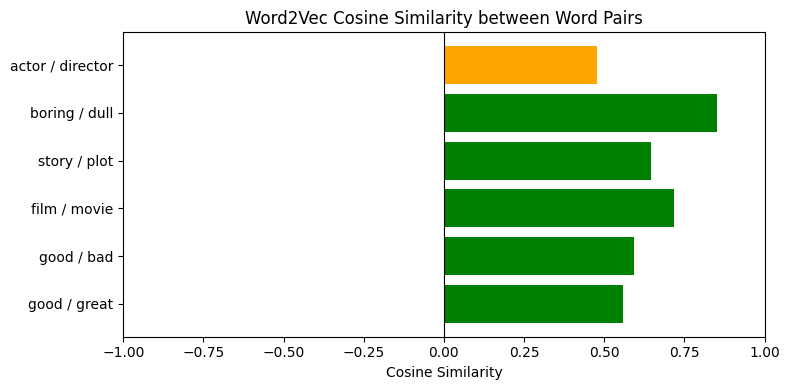

In [20]:
# Plot 8: Word2Vec - Cosine similarity between word pairs
word_pairs = [
    ('good', 'great'), ('good', 'bad'), ('film', 'movie'),
    ('story', 'plot'), ('boring', 'dull'), ('actor', 'director')
]

pair_labels = []
pair_scores = []

for w1, w2 in word_pairs:
    if w1 in w2v_model.wv and w2 in w2v_model.wv:
        score = w2v_model.wv.similarity(w1, w2)
        pair_labels.append(f'{w1} / {w2}')
        pair_scores.append(score)

plt.figure(figsize=(8, 4))
colors = ['green' if s > 0.5 else 'orange' if s > 0 else 'red' for s in pair_scores]
plt.barh(pair_labels, pair_scores, color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Word2Vec Cosine Similarity between Word Pairs')
plt.xlabel('Cosine Similarity')
plt.xlim(-1, 1)
plt.tight_layout()
plt.show()

In [21]:
# Final Summary
print('NLP Pipeline Summary')
print('=' * 50)
print(f'Dataset:               IMDB Movie Reviews')
print(f'Total reviews used:    {len(df)}')
print(f'Avg tokens (raw):      {df["tokens"].apply(len).mean():.0f}')
print(f'Avg tokens (cleaned):  {df["token_count"].mean():.0f}')
print(f'Vocabulary size:       {len(vocab)}')
print(f'BoW matrix shape:      {bow_matrix.shape}')
print(f'TF-IDF matrix shape:   {tfidf_matrix.shape}')
print(f'Word2Vec vocab size:   {len(w2v_model.wv)}')
print(f'Embedding dimensions:  {w2v_model.vector_size}')
print(f'Sentence emb shape:    {embedding_matrix.shape}')
print('=' * 50)
print('Pipeline complete.')

NLP Pipeline Summary
Dataset:               IMDB Movie Reviews
Total reviews used:    2000
Avg tokens (raw):      223
Avg tokens (cleaned):  117
Vocabulary size:       28223
BoW matrix shape:      (2000, 5000)
TF-IDF matrix shape:   (2000, 5000)
Word2Vec vocab size:   12586
Embedding dimensions:  100
Sentence emb shape:    (2000, 100)
Pipeline complete.
